# Análisis estadístico de Datos

## Objetivos
1. Diferenciar entre variables discretas y continuas, identificando ejemplos y aplicaciones en análisis de datos reales.
2. Aplicar técnicas de análisis exploratorio para describir y visualizar la distribución de variables numéricas.
3. Calcular e interpretar medidas de tendencia central y dispersión, como media, mediana, moda, varianza y desviación estándar.
4. Detectar y analizar valores atípicos (outliers) utilizando métodos como la regla de las 3 sigmas y el rango intercuartílico (IQR).
5. Explorar la relación entre variables mediante el uso de covarianza, gráficos de dispersión, interpretando patrones y asociaciones en los datos.

## 🔢 Variables Discretas y Continuas



### 📌 Variables Discretas
**Definición:**  
Toman valores enteros y contables. (**Pueden contarse**)


**Ejemplos:**
- 🎓 Número de estudiantes en un salón  
- 🎲 Número que cae en un dado  
- 🏆 Cantidad de premios ganados  
- 📦 Número de productos en inventario  

---

### 📈 Variables Continuas
**Definición:**  
Pueden tomar cualquier valor en un rango. (**Pueden medirse**)


**Ejemplos:**
- 📏 Altura de una persona (ej. 1.75 m)  
- 💸 Precio de un producto (ej. \$99.99)  
- ⏱ Tiempo en correr 100m (ej. 10.45 s)  
- 🌡 Temperatura ambiente (ej. 22.6 °C)  

## Caso de estudio: Análisis de Pesos y Alturas


📍**Contexto:**  
La empresa *VitalTrack*, dedicada a seguros de vida y bienestar corporativo en EE. UU., ha lanzado un nuevo programa llamado **"HealthCheck360"**. Como parte del programa, los nuevos clientes completan un formulario inicial con información sobre su altura y peso. Estos datos se usan para estimar el nivel de riesgo y diseñar programas personalizados de salud.

📊 La empresa ha recopilado una muestra de **10,000 registros** de personas que aplicaron al programa en los últimos 12 meses. Los datos incluyen el género, la altura (en pulgadas) y el peso (en libras) de cada individuo.

---

🧩 **Objetivos del análisis:**  
Tú eres parte del equipo de analítica de datos de *VitalTrack*. Te han asignado analizar esta base con dos objetivos:

1. **Detectar valores atípicos y errores de captura:**  
   Hay sospechas de que algunos registros contienen datos erróneos (como personas con más de 8 pies de altura o pesos muy inusuales), lo que podría afectar los modelos de evaluación de riesgo. Debes identificarlos y recomendar cómo tratarlos.

2. **Explorar patrones por género y relación entre altura y peso:**  
   El equipo de diseño del programa quiere saber si hay diferencias notables entre hombres y mujeres en cuanto a altura y peso promedio, y si existe una relación predecible entre ambos para generar recomendaciones personalizadas de salud.

---

🔍 **Preguntas clave que debes responder:**

* ¿Cuáles son los valores extremos o inconsistentes en los datos?  
* ¿Qué tan fuerte es la correlación entre altura y peso?  
* ¿Existen diferencias marcadas entre hombres y mujeres en las distribuciones de altura y peso?

---


### Cargar y explorar los datos


- Carga el archivo `weight-height.csv`.
- Muestra los primeros registros.
- Verifica los tipos de datos

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
PATH="https://raw.githubusercontent.com/zyntonyson/bootcamp_ds_da/refs/heads/main/datasets/weight-height.csv"
weight_height=pd.read_csv(PATH)

In [3]:
weight_height.head()

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801


In [4]:
weight_height.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB


### Análisis exploratorio de Datos

##### 🧠 Preguntas de interés

1. ¿Cómo se comporta el peso en la población?
2. ¿Qué peso es el representativo de la población?

#### 📚 Resumen de conceptos clave: Estadística Descriptiva

##### Medidas de tendencial central y dispersión

1. **📏 Media y Mediana (Medidas de posición)**
- **Media**: Promedio de los datos. Sensible a valores atípicos.
- **Mediana**: Valor central. No se ve afectada por extremos.

2. **📊 Varianza**
- Mide la dispersión promedio al **elevar al cuadrado** la distancia de cada valor respecto a la media.
- Una varianza alta indica que los datos están muy dispersos.

3. **📉 Desviación Estándar**
- Es la raíz cuadrada de la varianza, con las **mismas unidades** que los datos originales.
- Muy útil para interpretar la variabilidad de los datos y definir rangos de normalidad.

In [5]:
# Medidas de tendencia central
print(f"Media: {weight_height['Weight'].mean()}")
print(f"Mediana: {weight_height['Weight'].median()}")
print(f"Moda: {weight_height['Weight'].mode().values}")

# Medidas de dispersión
print(f"Desviación estándar: {weight_height['Weight'].std()}")
print(f"Varianza: {weight_height['Weight'].var()}")
print(f"Mínimo: {weight_height['Weight'].min()}")
print(f"Máximo: {weight_height['Weight'].max()}")
print(f"Rango: {weight_height['Weight'].max() - weight_height['Weight'].min()}")

Media: 161.44035683283076
Mediana: 161.21292769948298
Moda: [ 64.70012671  68.98253009  71.39374874 ... 255.69083484 255.86332649
 269.98969851]
Desviación estándar: 32.108439006519596
Varianza: 1030.9518554353892
Mínimo: 64.700126712753
Máximo: 269.989698505106
Rango: 205.289571792353


In [6]:
# Resumen estadistico de las variables
weight_height.describe()

,Height,Weight
count,10000.000000,10000.000000
mean,66.367560,161.440357
std,3.847528,32.108439
min,54.263133,64.700127
25%,63.505620,135.818051
50%,66.318070,161.212928
75%,69.174262,187.169525
max,78.998742,269.989699


**Visualizemos como de dispersan los datos**

#### Histogramas y gráficos de densidad


 📊  Histograma vs KDE

| Característica                  | Histograma 🟦                           | KDE 📈                                      |
|--------------------------------|----------------------------------------|---------------------------------------------|
| **Tipo de visualización**      | Barras por intervalos (bins)           | Curva continua que suaviza la distribución  |
| **Dependencia del parámetro**  | Sensible al número y tamaño de los bins| Sensible al ancho de banda (bandwidth)      |
| **Precisión de la forma**      | Aproximada, puede verse segmentada     | Más precisa, revela patrones suaves         |
| **Interpretación del eje Y**   | Frecuencia (o densidad si se especifica)| Densidad de probabilidad                    |
| **Uso recomendado**            | Exploración inicial o variables discretas| Comparación de distribuciones continuas     |

c:\Users\roman\Documents\proyectos\tripleten\bootcamp_ds_da\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


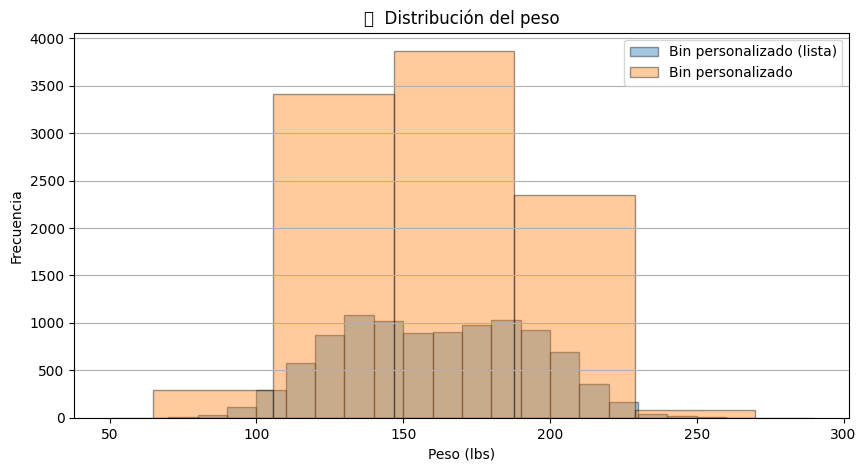

In [7]:
# 📊 Histograma con intervalos personalizados
bins = list(range(50, 300, 10))  # Intervalos de 3 entre 35 y 55
plt.figure(figsize=(10, 5))

plt.hist(weight_height['Weight'], bins=bins, alpha=0.4, edgecolor='black',label='Bin personalizado (lista)')
plt.hist(weight_height['Weight'], bins=5, alpha=0.4, edgecolor='black', label='Bin personalizado')
plt.title("📈  Distribución del peso")
plt.legend()
plt.xlabel("Peso (lbs)")
plt.ylabel("Frecuencia")
plt.grid(axis='y')
plt.show()


c:\Users\roman\Documents\proyectos\tripleten\bootcamp_ds_da\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


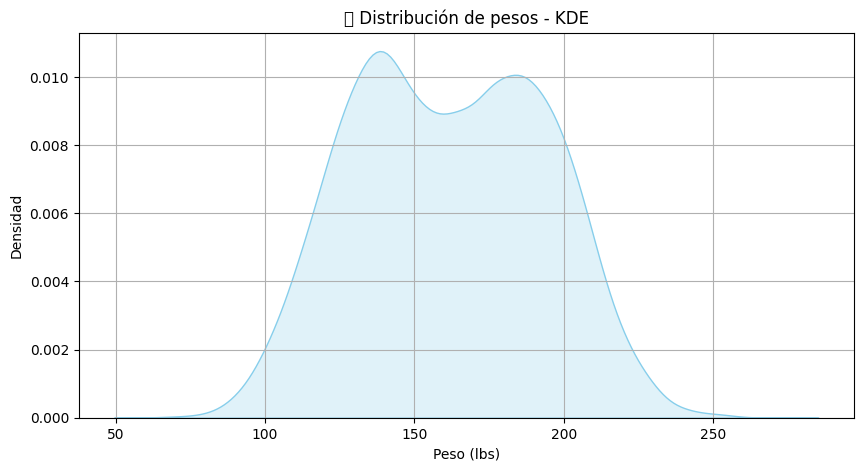

In [8]:
# 📈 Gráfico de densidad (KDE)
plt.figure(figsize=(10, 5))
sns.kdeplot(weight_height['Weight'], fill=True, color='skyblue')
plt.title("📈 Distribución de pesos - KDE")
plt.xlabel("Peso (lbs)")
plt.ylabel("Densidad")
plt.grid()
plt.show()

##### 🧠 Preguntas para Reflexionar

1. 🧮 ¿Qué forma tiene la distribución de los peso?
2. 🎯 ¿Cuál es el rango de pesos más común?
3. 📉 ¿Qué ventajas aporta el gráfico de densidad (KDE) respecto al histograma?
4. 🔍 ¿La distribución parece simétrica o presenta sesgo (inclinación) hacia algún lado?


In [9]:
(weight_height.groupby('Gender')
  .agg(
      media=('Weight','mean'),
      mediana=('Weight','median'),
      min=('Weight','min'),
      max=('Weight','max'),
      std=('Weight','std'),
      var=('Weight','var')
  ))

,media,mediana,min,max,std,var
Gender,,,,,,
Female,135.860093,136.117583,64.700127,202.237214,19.022468,361.854281
Male,187.020621,187.033546,112.902939,269.989699,19.781155,391.294074


In [10]:
weight_height.groupby('Gender')['Weight'].describe()

,count,mean,std,min,25%,50%,75%,max
Gender,,,,,,,,
Female,5000.0,135.860093,19.022468,64.700127,122.934096,136.117583,148.810926,202.237214
Male,5000.0,187.020621,19.781155,112.902939,173.887767,187.033546,200.357802,269.989699


#### 4. 📦 Cuartiles e IQR (Rango Intercuartílico)
- Q1: percentil 25, Q2: mediana (50%), Q3: percentil 75.
- **IQR = Q3 - Q1**, describe la dispersión del 50% central de los datos.


- Genera un **boxplot** que compare el peso por genero.
- Genera un **histograma con KDE** para el peso de los hombres.
  - Añade líneas verticales con la media y la mediana.
  - ¿Cómo se distribuyen los datos?


Text(0, 0.5, 'Peso (lbs)')

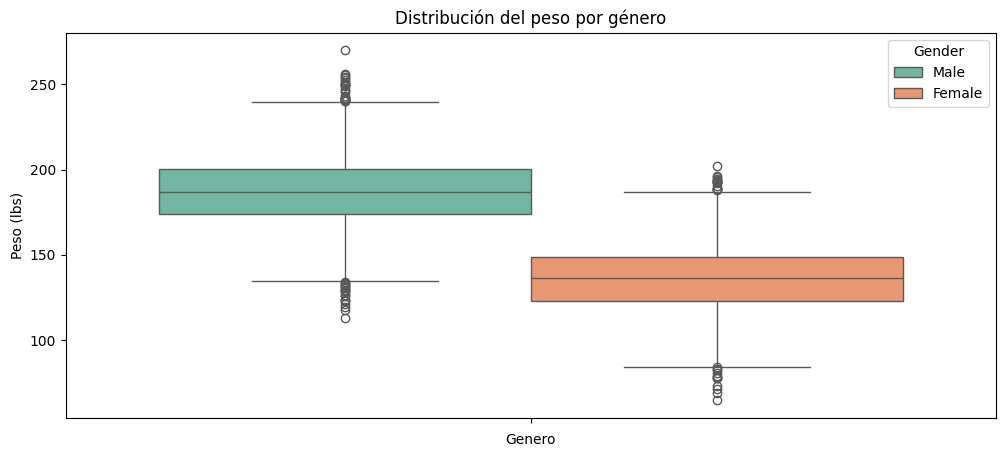

In [11]:
plt.figure(figsize=(12, 5))
sns.boxplot(data=weight_height, hue='Gender', y='Weight', palette='Set2')
plt.title('Distribución del peso por género')
plt.xticks(rotation=45)
plt.xlabel('Genero')
plt.ylabel('Peso (lbs)')

c:\Users\roman\Documents\proyectos\tripleten\bootcamp_ds_da\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


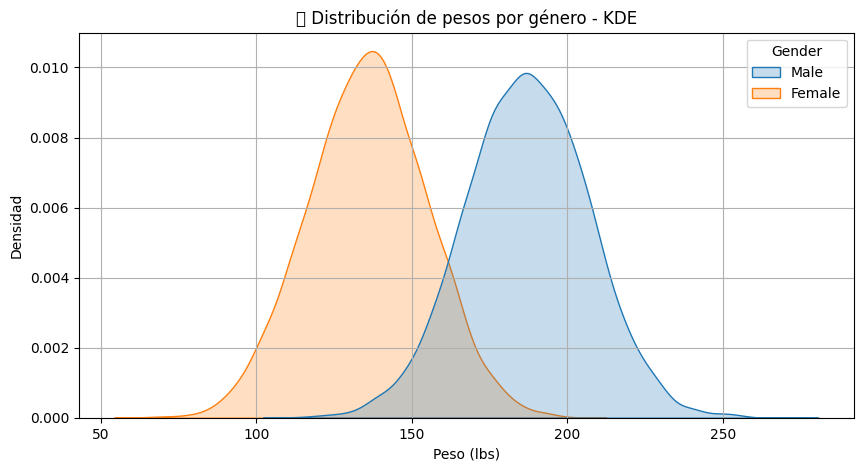

In [12]:
# 📈 Gráfico de densidad (KDE)
plt.figure(figsize=(10, 5))
sns.kdeplot(data=weight_height, x='Weight', fill=True, color='skyblue',hue='Gender')
plt.title("📈 Distribución de pesos por género - KDE")
plt.xlabel("Peso (lbs)")
plt.ylabel("Densidad")
plt.grid()
plt.show()

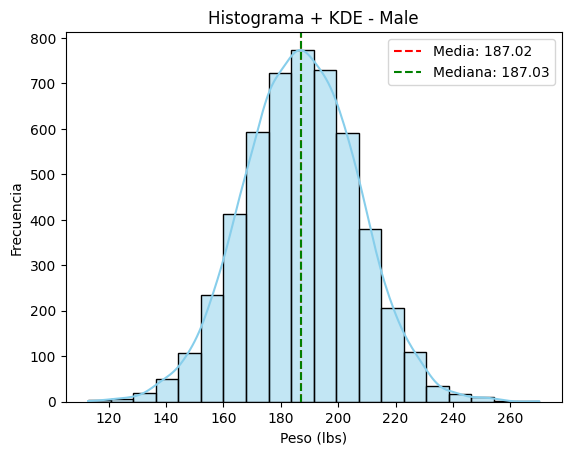

In [13]:
df_male = weight_height[weight_height['Gender'] == "Male"]
media = df_male['Weight'].mean()
mediana = df_male['Weight'].median()
sns.histplot(df_male['Weight'], bins=20, kde=True, color='skyblue')
plt.axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.2f}')
plt.title('Histograma + KDE - Male')
plt.xlabel('Peso (lbs)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

#### 5. 🛎 Distribución Normal y la Regla de las 3 Sigmas
- Distribución simétrica en forma de campana.
- **Regla**:
  - 68% de los valores dentro de ±1σ
  - 95% dentro de ±2σ
  - 99.7% dentro de ±3σ


- Calcula el intervalo de la regla de las 3 sigmas para el peso de los hombres.

In [14]:
# 1️⃣ Calcular media y desviación estándar
media = df_male['Weight'].mean()
std = df_male['Weight'].std()
total_casos = df_male.shape[0]

# 2️⃣ Calcular los límites de ±3σ
limite_inferior = media - 3 * std
limite_superior = media + 3 * std

print(f"Intervalo de la regla de 3 sigma(s): ({limite_inferior:.2f}, {limite_superior:.2f})")

Intervalo de la regla de 3 sigma(s): (127.68, 246.36)


In [15]:
def n_sigmas(sigma):
    if sigma < 1:
        return "Dentro de 1 sigma"
    elif sigma < 2:
        return "Dentro de 2 sigmas"
    elif sigma <3:
        return "Dentro de 3 sigmas"
    else:
        return "Más de 3 sigmas"
        

(
    df_male
    .assign(
        n_sigma = lambda df: abs(df['Weight'] - media) / std,
        n_sigma_tag = lambda df: df['n_sigma'].apply(n_sigmas)
    )
    .groupby('n_sigma_tag')
    .agg(
        count=('n_sigma', 'count'),
        min=('Weight', 'min'),
        max=('Weight', 'max')
    )
    .assign(
        percentage=lambda df: 100*(df['count'] / total_casos),
        cumulative = lambda df: df['percentage'].cumsum() 
    )
)

,count,min,max,percentage,cumulative
n_sigma_tag,,,,,
Dentro de 1 sigma,3436,167.284904,206.790142,68.72,68.72
Dentro de 2 sigmas,1330,147.537956,226.503344,26.60,95.32
Dentro de 3 sigmas,212,128.390221,246.232321,4.24,99.56
Más de 3 sigmas,22,112.902939,269.989699,0.44,100.00


#### 6. 🚨 Valores Atípicos (Outliers)
- Puntos fuera de **1.5 × IQR** desde Q1 o Q3.
- Su detección es fundamental para entender desviaciones o errores en los datos.

- Verifica si hay valores fuera de ese rango (posibles valores atípicos) para las regla 3 sigma

In [16]:
# 3️⃣ Verificar qué valores están fuera del intervalo
fuera_de_rango = df_male[(df_male['Weight'] < limite_inferior) | (df_male['Weight'] > limite_superior)]

print(f"Número de valores fuera del rango: {fuera_de_rango.shape[0]}")
print(f"Valores fuera del rango:\n{fuera_de_rango}")

Número de valores fuera del rango: 22
Valores fuera del rango:
     Gender     Height      Weight
565    Male  61.754010  123.528143
994    Male  78.095867  255.690835
1506   Male  75.698618  249.565628
1610   Male  76.617546  255.863326
1750   Male  74.604668  249.946283
1942   Male  59.981865  112.902939
2014   Male  78.998742  269.989699
2070   Male  77.465569  252.556689
2417   Male  63.154272  119.242856
2500   Male  61.074487  122.680112
2527   Male  60.269108  126.455613
2873   Male  61.136475  125.827022
2971   Male  75.156879  250.317151
3228   Male  76.268668  247.386741
3285   Male  78.528210  253.889004
3332   Male  60.721080  123.628360
3669   Male  77.008336  251.425051
3909   Male  77.067355  249.110242
4077   Male  74.976953  248.848873
4331   Male  76.848761  254.209073
4637   Male  59.868078  117.803842
4794   Male  58.406905  121.338323


- ¿Qué porcentaje de los datos cae fuera de ±3σ?

In [17]:
# 4️⃣ Calcular porcentaje de datos fuera de ±3σ
total = df_male.shape[0]
porcentaje_fuera = (fuera_de_rango.shape[0] / total_casos) * 100

print(f"📊 Porcentaje de datos fuera de ±3σ: {porcentaje_fuera:.2f}%")

📊 Porcentaje de datos fuera de ±3σ: 0.44%


- Detectar outliers con IQR
    - Calcula **Q1**, **Q3** y el **IQR** para los pesos.

In [18]:
# Calcular Q1, Q3 e IQR
q1 = df_male['Weight'].quantile(0.25)
q3 = df_male['Weight'].quantile(0.75)
iqr = q3 - q1

print(f"Q1: {q1:.2f}, Q3: {q3:.2f}, IQR: {iqr:.2f}")

Q1: 173.89, Q3: 200.36, IQR: 26.47


In [19]:
# Calcular límites inferior y superior
limite_inferior = q1 - 1.5 * iqr
limite_superior = q3 + 1.5 * iqr

print(f"Límite inferior: {limite_inferior:.2f}")
print(f"Límite superior: {limite_superior:.2f}")

Límite inferior: 134.18
Límite superior: 240.06


- Cuenta cuántos **outliers** hay y menciona sus valores.

In [20]:
# Detectar outliers
outliers = df_male[(df_male['Weight'] < limite_inferior) | (df_male['Weight'] > limite_superior)]

# Mostrar resultados
print(f"Cantidad de outliers detectados: {outliers.shape[0]}")
print("Valores de tiempo considerados outliers:")
sorted(outliers['Weight'].values.tolist())

Cantidad de outliers detectados: 46
Valores de tiempo considerados outliers:


[112.902939447818,
 117.803841692011,
 119.242855919903,
 121.338322555937,
 122.680111752611,
 123.528143020198,
 123.628359577062,
 125.827021940119,
 126.455612757901,
 128.39022102706,
 128.724049595521,
 129.291982421435,
 129.301023766729,
 130.277274850818,
 130.838073839864,
 131.800702916443,
 132.26298045314,
 132.948178886676,
 133.511983471512,
 134.146848185454,
 240.44081593557,
 240.455351800759,
 240.536796698663,
 240.638103496331,
 240.8517285055,
 240.94226656803,
 241.202330051514,
 241.686601265952,
 241.893563180437,
 242.041172648909,
 243.267497419798,
 245.733782726093,
 246.232321295104,
 247.38674101635,
 248.8488726642,
 249.110241600421,
 249.5656279814,
 249.946283195065,
 250.317150668765,
 251.425050545674,
 252.556689436658,
 253.889003841814,
 254.209073180735,
 255.690834836788,
 255.863326492899,
 269.989698505106]




#### 7. ↕️ Sesgo (Asimetría)
- **Sesgo positivo (derecha)**: Media > Mediana.
- **Sesgo negativo (izquierda)**: Media < Mediana.
- Puede detectarse visualmente en histogramas o boxplots.




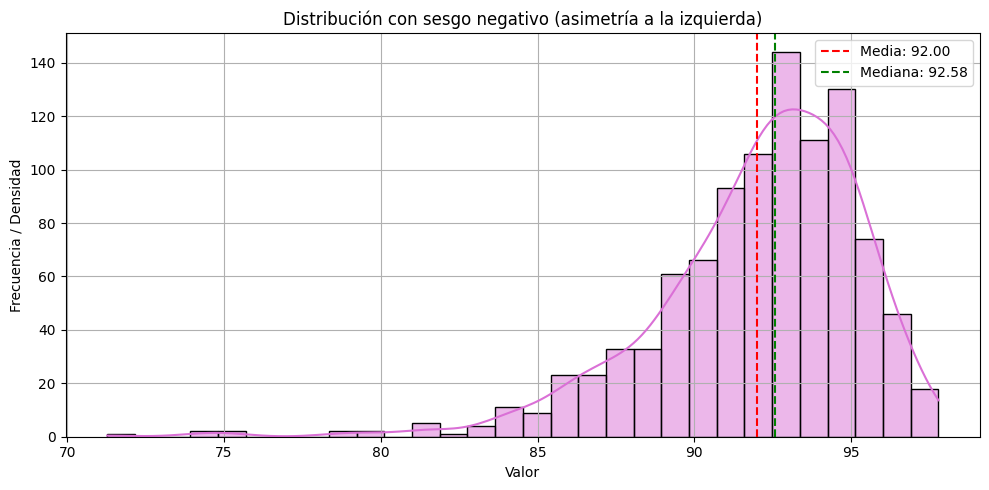

In [21]:
# Distribución normal modificada para sesgo negativo
data_neg = np.random.normal(loc=50, scale=10, size=1000)
data_neg = -np.exp(data_neg / 25) + 100  # transforma para sesgo negativo

# Calcular media y mediana
media_neg = np.mean(data_neg)
mediana_neg = np.median(data_neg)

# Plot KDE + Histograma
plt.figure(figsize=(10, 5))
sns.histplot(data_neg, kde=True, bins=30, color='orchid')
plt.axvline(media_neg, color='red', linestyle='--', label=f'Media: {media_neg:.2f}')
plt.axvline(mediana_neg, color='green', linestyle='--', label=f'Mediana: {mediana_neg:.2f}')
plt.title("Distribución con sesgo negativo (asimetría a la izquierda)")
plt.xlabel("Valor")
plt.ylabel("Frecuencia / Densidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

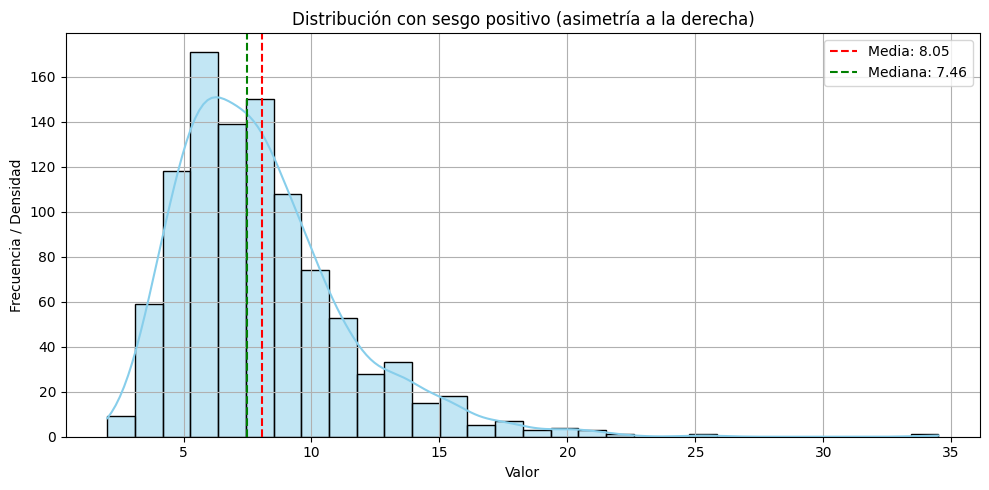

In [22]:
# Semilla para reproducibilidad
np.random.seed(42)

# Distribución normal modificada para sesgo positivo
data_pos = np.random.normal(loc=50, scale=10, size=1000)
data_pos = np.exp(data_pos / 25)  # transforma para sesgo positivo

# Calcular media y mediana
media_pos = np.mean(data_pos)
mediana_pos = np.median(data_pos)

# Plot KDE + Histograma
plt.figure(figsize=(10, 5))
sns.histplot(data_pos, kde=True, bins=30, color='skyblue')
plt.axvline(media_pos, color='red', linestyle='--', label=f'Media: {media_pos:.2f}')
plt.axvline(mediana_pos, color='green', linestyle='--', label=f'Mediana: {mediana_pos:.2f}')
plt.title("Distribución con sesgo positivo (asimetría a la derecha)")
plt.xlabel("Valor")
plt.ylabel("Frecuencia / Densidad")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**La distribución de pesos en hombres, ¿tiene algún sesgo?**

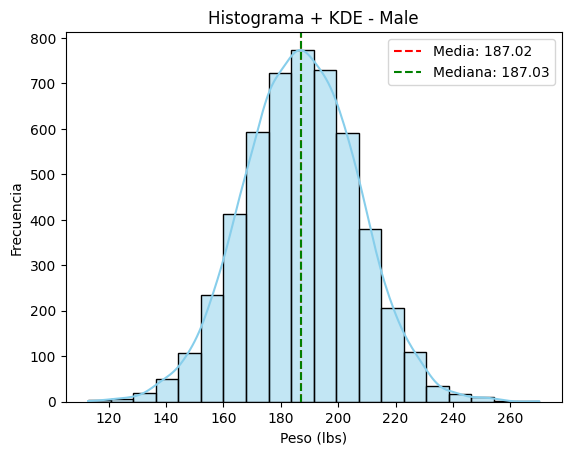

In [23]:
df_male = weight_height[weight_height['Gender'] == "Male"]
media = df_male['Weight'].mean()
mediana = df_male['Weight'].median()
sns.histplot(df_male['Weight'], bins=20, kde=True, color='skyblue')
plt.axvline(media, color='red', linestyle='--', label=f'Media: {media:.2f}')
plt.axvline(mediana, color='green', linestyle='--', label=f'Mediana: {mediana:.2f}')
plt.title('Histograma + KDE - Male')
plt.xlabel('Peso (lbs)')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

#### 8. 🔗 Covarianza
- Mide cómo **varían conjuntamente** dos variables.
  - Positiva: ambas suben o bajan juntas.
  - Negativa: cuando una sube, la otra baja.
  - Cero: no hay relación lineal clara.


> 🔎 El valor numérico de la varianza y la covarianza no tiene una interpretación directa sencilla por sus unidades combinadas. Se usan principalmente para describir la dispersión y la relación entre variables, pero para comparar o interpretar mejor, se suele usar la desviación estándar (para varianza) y la correlación (para covarianza).

**Analizar relación entre variables**
- Usa un **diagrama de dispersión** para visualizar la relación entre peso y la estatura.

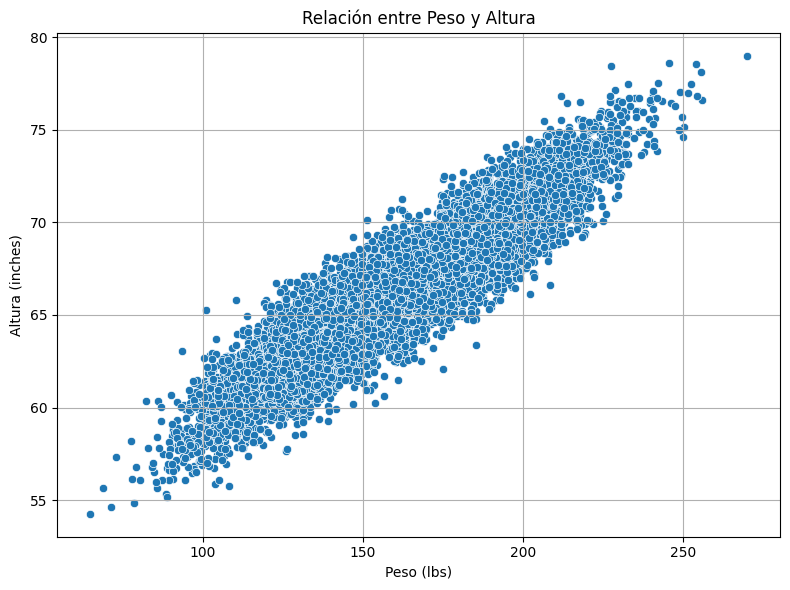

In [24]:
# 1️⃣ Diagrama de dispersión
plt.figure(figsize=(8, 6))
sns.scatterplot(data=weight_height, x='Weight', y='Height')
plt.title('Relación entre Peso y Altura')
plt.xlabel('Peso (lbs)')
plt.ylabel('Altura (inches)')
plt.grid(True)
plt.tight_layout()
plt.show()

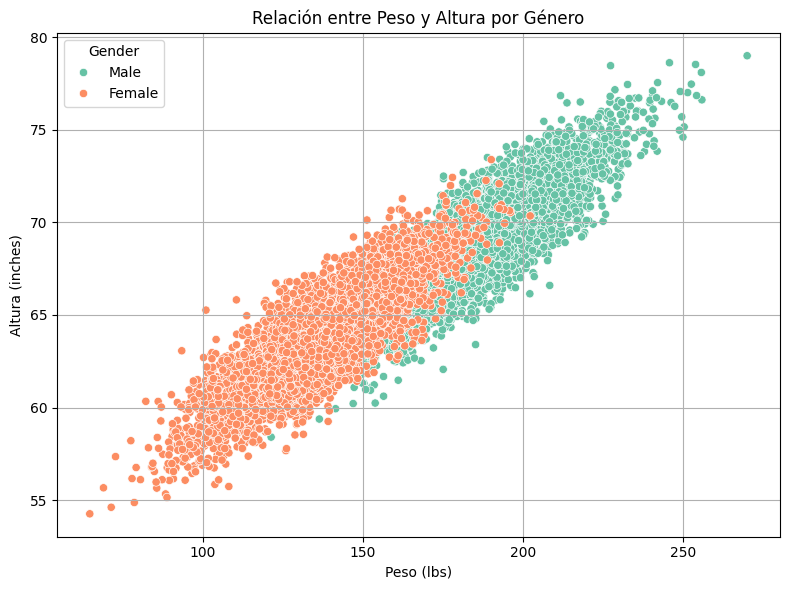

In [25]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=weight_height, x='Weight', y='Height',hue='Gender', palette='Set2')
plt.title('Relación entre Peso y Altura por Género')
plt.xlabel('Peso (lbs)')
plt.ylabel('Altura (inches)')
plt.grid(True)
plt.tight_layout()
plt.show()

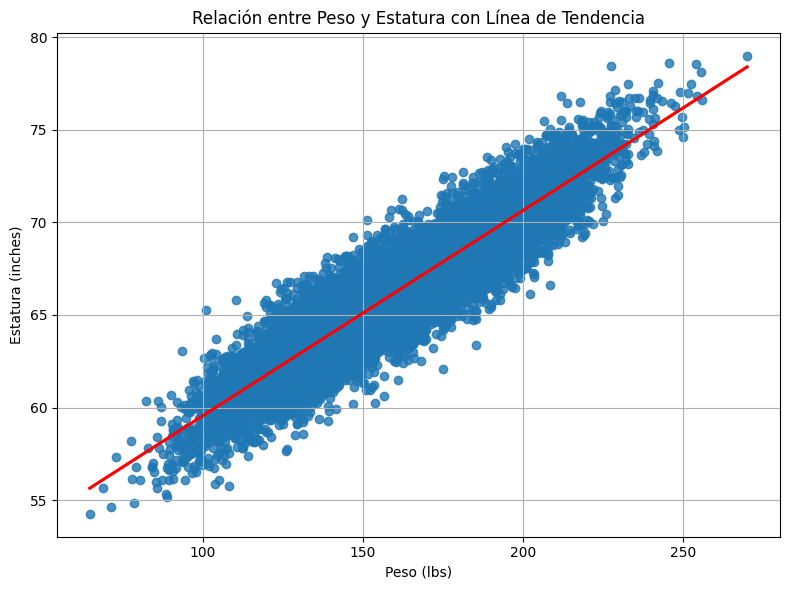

In [26]:
plt.figure(figsize=(8, 6))
sns.regplot(data=weight_height, x='Weight', y='Height', scatter=True, line_kws={'color': 'red'})
plt.title('Relación entre Peso y Estatura con Línea de Tendencia')
plt.xlabel('Peso (lbs)')
plt.ylabel('Estatura (inches)')
plt.grid(True)
plt.tight_layout()
plt.show()

- Calcula la **covarianza** entre estas dos variables.
- ¿Existe una relación lineal aparente?

In [27]:
# 2️⃣ Calcular covarianza
covarianza = weight_height[['Weight', 'Height']].cov().iloc[0, 1]
print(f'📊 Covarianza entre Peso y altura: {covarianza:.2f}')

# 3️⃣ Interpretación :
if covarianza > 0:
    print("↗️ Existe una relación positiva: a más altura, se espera mayor peso.")
elif covarianza < 0:
    print("↘️ Existe una relación negativa: a menos altura, se espera menor peso.")
else:
    print("➖ No hay relación lineal aparente.")

📊 Covarianza entre Peso y altura: 114.24
↗️ Existe una relación positiva: a más altura, se espera mayor peso.


## Resumen

1. **Diferenciación de variables:**  
   Aprendiste a distinguir entre variables discretas (valores contables) y continuas (valores medibles).

2. **Análisis exploratorio y estadística descriptiva:**  
   Aplicaste técnicas para describir y visualizar la distribución de variables numéricas, utilizando medidas como media, mediana, moda, varianza y desviación estándar.

3. **Detección y análisis de valores atípicos:**  
   Utilizaste métodos como la regla de las 3 sigmas y el rango intercuartílico (IQR) para identificar outliers y comprender su impacto en los datos.

4. **Visualización de datos:**  
   Generaste histogramas, gráficos de densidad (KDE), boxplots y diagramas de dispersión para interpretar la forma, dispersión y relaciones en los datos.

5. **Relación entre variables:**  
   Exploraste la relación entre altura y peso mediante covarianza, correlación y gráficos de dispersión, identificando patrones y diferencias por género.